In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv(
    'Environmental_Data_Deep_Moor_2015.csv')

In [21]:
def hours_dict(date):
    day = df[df['date']==date]
    hours = [time.split(':')[0] for time in day['time']]
    hours_dict = {i:hours.count(str(i)) for i in np.arange(24)}
    return hours_dict

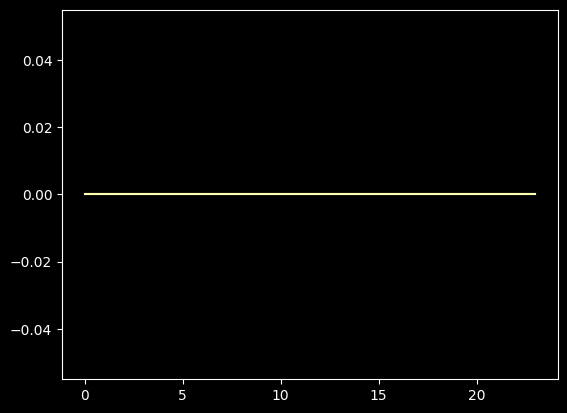

In [37]:
feb15 = hours_dict("'2015_02_15")
plt.plot(feb15.keys(), feb15.values())
plt.show()

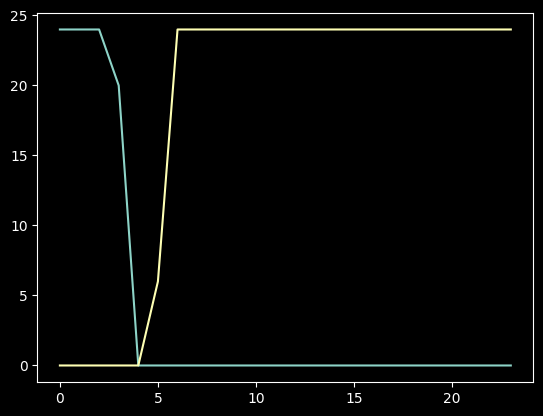

In [39]:
feb15 = hours_dict('2015_02_15')
feb16 = hours_dict('2015_02_16')
plt.plot(feb15.keys(), feb15.values())
plt.plot(feb16.keys(), feb16.values())
plt.show()

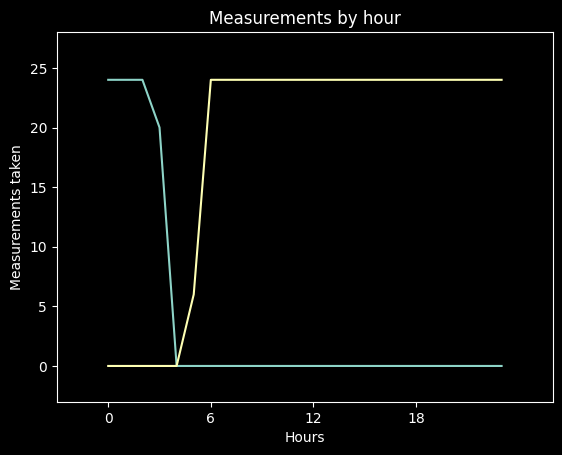

In [41]:
feb15 = hours_dict('2015_02_15')
feb16 = hours_dict('2015_02_16')
plt.plot(feb15.keys(), feb15.values())
plt.plot(feb16.keys(), feb16.values())
plt.xticks(np.arange(0,24,6))
plt.xlim(-3,26)
plt.ylim(-3,28)
plt.xlabel('Hours')
plt.ylabel('Measurements taken')
plt.title('Measurements by hour')
plt.show()

In [50]:
# %load ../get_df.py
def get_df(yr):
    return pd.read_csv("../Environmental_Data_Deep_Moor_{}.csv".format(yr))

In [53]:
# %load ../line_helpers.py
def monthly_avg_calc(mo,col):
    return df[df['date'].str.contains('201[2345]_[0]?'+ str(mo))][col].mean()


In [48]:
def yearly_avg(category):
    return list(map(lambda m: monthly_avg_calc(m, category), range(1,13)))

In [51]:
df = get_df('2014')

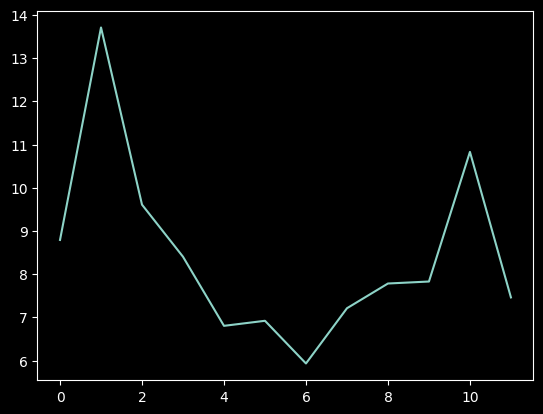

In [54]:
plt.plot(yearly_avg('Wind_Speed'))
plt.show()

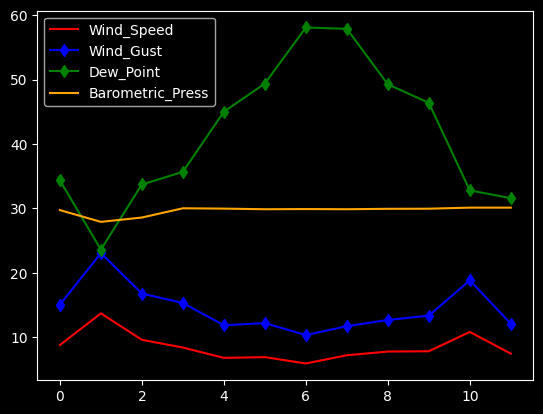

In [59]:
plt.plot(yearly_avg('Wind_Speed'), label='Wind_Speed', color='red')
plt.plot(yearly_avg('Wind_Gust'), 'd-', label='Wind_Gust', color='blue')
plt.plot(yearly_avg('Dew_Point'), 'd-', label='Dew_Point', color='green')
plt.plot(yearly_avg('Barometric_Press'), label='Barometric_Press', color='orange')
plt.legend()
plt.show()

In [63]:
# %load ../get_seasons.py
def get_seasons(yr):
    df = get_df(yr)
    return [df[df['date'].between('{}_03_20'.format(yr),'{}_06_19'.format(yr))],
            df[df['date'].between('{}_06_20'.format(yr),'{}_09_21'.format(yr))],
            df[df['date'].between('{}_09_22'.format(yr),'{}_12_20'.format(yr))],
            df[~df['date'].between('{}_03_20'.format(yr),'{}_12_20'.format(yr))]]

In [68]:
seasons = ["Spring", "Summer", "Fall", "Winter"]
heights = [season['Air_Temp'].mean() for season in get_seasons('2013')]

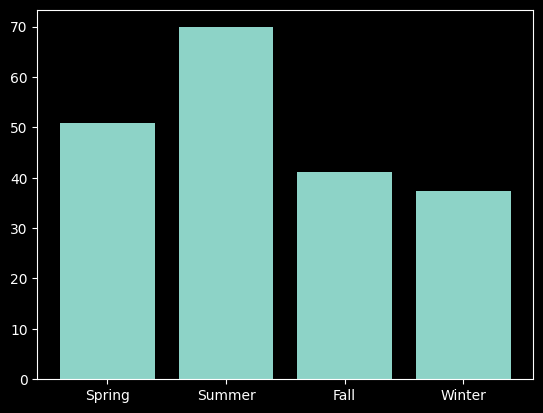

In [69]:
plt.bar(seasons, heights)
plt.show()

In [72]:
alphas = [height/max(heights) for height in heights]
colors = [(.1,.7,.2,a) for a in alphas]

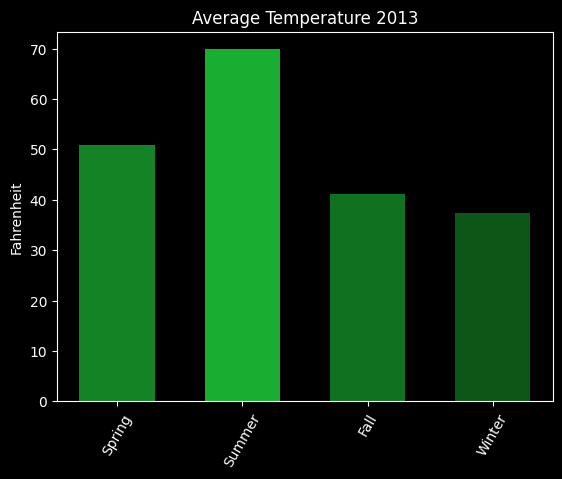

In [77]:
plt.bar(seasons, heights, .6, color=colors)
plt.ylabel('Fahrenheit')
plt.xticks(rotation=60)
plt.title('Average Temperature 2013')
plt.show()

In [86]:
heights14 = [season['Air_Temp'].mean() for season in get_seasons('2014')]
alphas14 = [height/max(heights) for height in heights14]
colors = [(.1,.7,.2,a) for a in alphas14]
colors14 = [(.2,.8,.7,a) for a in alphas14]

Text(0.5, 1.0, 'Average Temperature 2014')

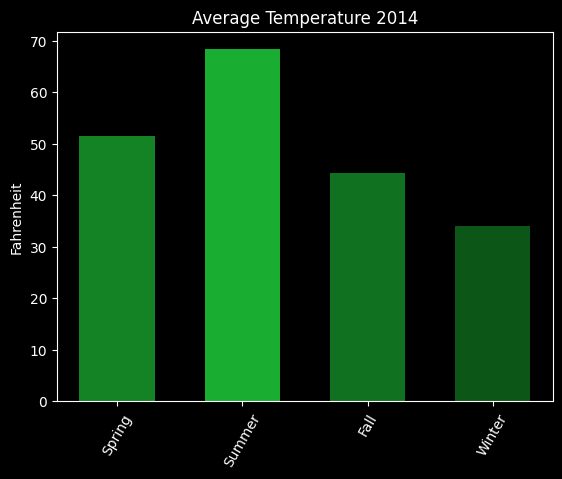

In [78]:
plt.bar(seasons, heights14, .6, color=colors)
plt.ylabel('Fahrenheit')
plt.xticks(rotation=60)
plt.title('Average Temperature 2014')

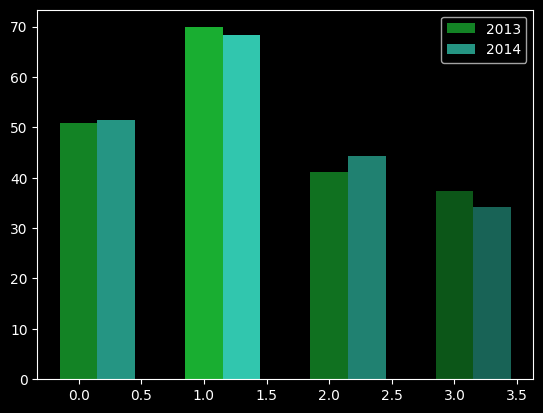

In [93]:
index = np.arange(4)
fig, ax = plt.subplots()
rects1 = ax.bar(index, heights, .3, color=colors, label='2013')
rects2 = ax.bar(index+.3, heights14, .3, color=colors14, label='2014')
ax.legend()
plt.show()

